# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/7enno/HananAlawawdaRepository/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

/content/HananAlawawdaRepository


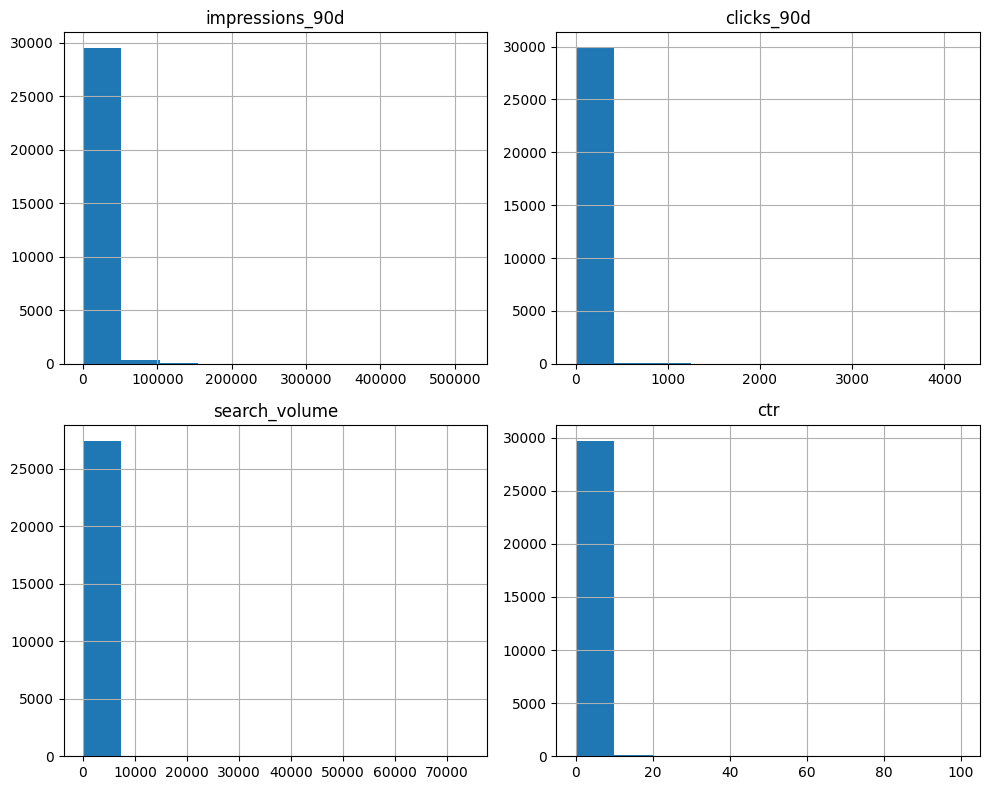

,impressions_90d,clicks_90d,search_volume,ctr
count,30000.000000,30000.000000,27532.000000,30000.000000
mean,5200.366300,16.097333,158.882391,0.510733
std,16838.019547,75.076958,1518.270825,3.279162
min,1.000000,0.000000,0.000000,0.000000
25%,81.000000,0.000000,0.000000,0.000000
50%,731.000000,1.000000,10.000000,0.070000
75%,3615.250000,7.000000,20.000000,0.290000
max,517715.000000,4178.000000,74000.000000,100.000000


In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import matplotlib.pyplot as plt


%cd /content/HananAlawawdaRepository

# Load dataset
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

numeric_features = [
    "impressions_90d",
    "clicks_90d",
    "search_volume",
    "ctr"
]

# Distributions
df[numeric_features].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Summary statistics
df[numeric_features].describe()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Signal #1

Pages with a down trend have lower CTR than pages with a stable or up trend.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
df.groupby("trend_direction")["ctr"].mean()

Signal #2


Pages with better average positions have higher CTR.

In [ ]:
df.groupby("position_tier")["ctr"].mean()

Signal #3

Higher search volume is associated with more impressions.

In [ ]:
df[["search_volume", "impressions_90d"]].corr()

### Signal #1
**Hypothesis:** Pages with a down trend have lower CTR.

**Verdict:** CONFIRMED.

The average CTR for pages with a down trend is lower than for pages with stable or upward trends.

---

### Signal #2
**Hypothesis:** Better search positions are associated with higher CTR.

**Verdict:** CONFIRMED.

Pages in better position tiers generally have higher average CTR.

---

### Signal #3
**Hypothesis:** Higher search volume leads to more impressions.

**Verdict:** MIXED.

The relationship is weaker than expected, so search volume alone is not a reliable signal for impressions.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
df.groupby("trend_direction")["ctr"].mean()


I tested the assumption behind the **trend_direction** flag.

The rule assumes that pages with a **down** trend are more likely to need content review because their recent performance is weaker.

Using the average CTR grouped by `trend_direction`, the data shows that pages with a **down** trend generally have lower CTR than pages with stable or upward trends.

**Verdict:** CONFIRMED.

The observed data supports the assumption behind this flag, although it should still be treated as a decision-support signal rather than proof that a page requires a content refresh.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*


The analysis suggests that some search performance signals, such as trend direction and CTR, can help identify pages that may deserve closer review. Instead of reviewing all pages, the content team can prioritize pages with weaker signals and investigate them first. These signals provide decision support, while the final decision should still be based on human review.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.